# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión


from scipy import stats

In [2]:
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

#font = {'size': 8}

#matplotlib.rc('font', **font)
#matplotlib.rc('xtick', labelsize=8)
#matplotlib.rc('ytick', labelsize=8)
#matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [4]:
#from google.colab import drive
#drive.mount('/content/drive')

In [5]:
#cargamos los datos como arreglos numpy
features= np.loadtxt("RRLyrae_features_small.txt", delimiter=',')
targets= np.loadtxt("RRLyrae_labels_small.txt", delimiter=',')


In [6]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


### Preguntas
**1. ¿Este es un problema de clasificación o regresión?**

- Es un problema de clasificación ya que se intenta encontrar los posibles candidatos a RR Lyrae.

**2. ¿Es un problema binario o multiclase?**

- Binario, debido a que las categorías son: es RR Lyrae o no es.

**3. ¿Qué representa la variable objetivo?**

- Si corresponde a la estrella pulsante RR Lyrae o no.

**4. ¿Las clases están balanceadas o desbalanceadas?**

- Las clases están desbalanceadas, pero no tanto.

**5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?**

- Porque resulta más díficil separar los datos.

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

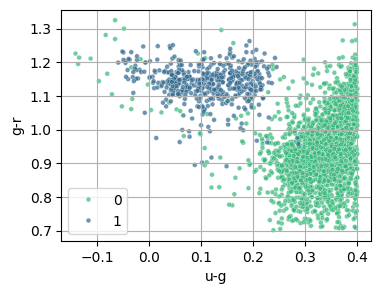

In [7]:
fig, ax = plt.subplots(figsize=(4,3))
sns.scatterplot(data=df, x="u-g", y="g-r", hue="RR_Lyrae", s = 12, alpha = 0.7, palette = "viridis_r")
ax.set_xlabel('u-g')
ax.set_ylabel('g-r')
ax.legend()
ax.grid()
plt.show()

### Pregunta
**1. ¿Se observan regiones donde las clases parecen separarse?**

- Si, de hecho se forman dos zonas, no perfectas, pero que separan los datos.

**2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?**

- Si ya que por los valores en los que se encuentran los datos podría ser más sencillo para el árbol separarlos

#### Separe los datos en entrenamiento y prueba

In [8]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=4)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

**1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?**

- Conjunto de entranemiento no será representativo.

**2. ¿Por qué eso podría afectar la evaluación del modelo?**

- Modelo puede parecer preciso y resultados no van a ser reproducibles

**3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?**

- Asegurarse que las proporciones de clases se mantengan iguales en todos los conjuntos.

#### Ahora entrenaremos un árbol de decisión (modelo base)

In [10]:
model_tree = DecisionTreeClassifier(random_state=42)

model_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

#### Visualicemos el árbol

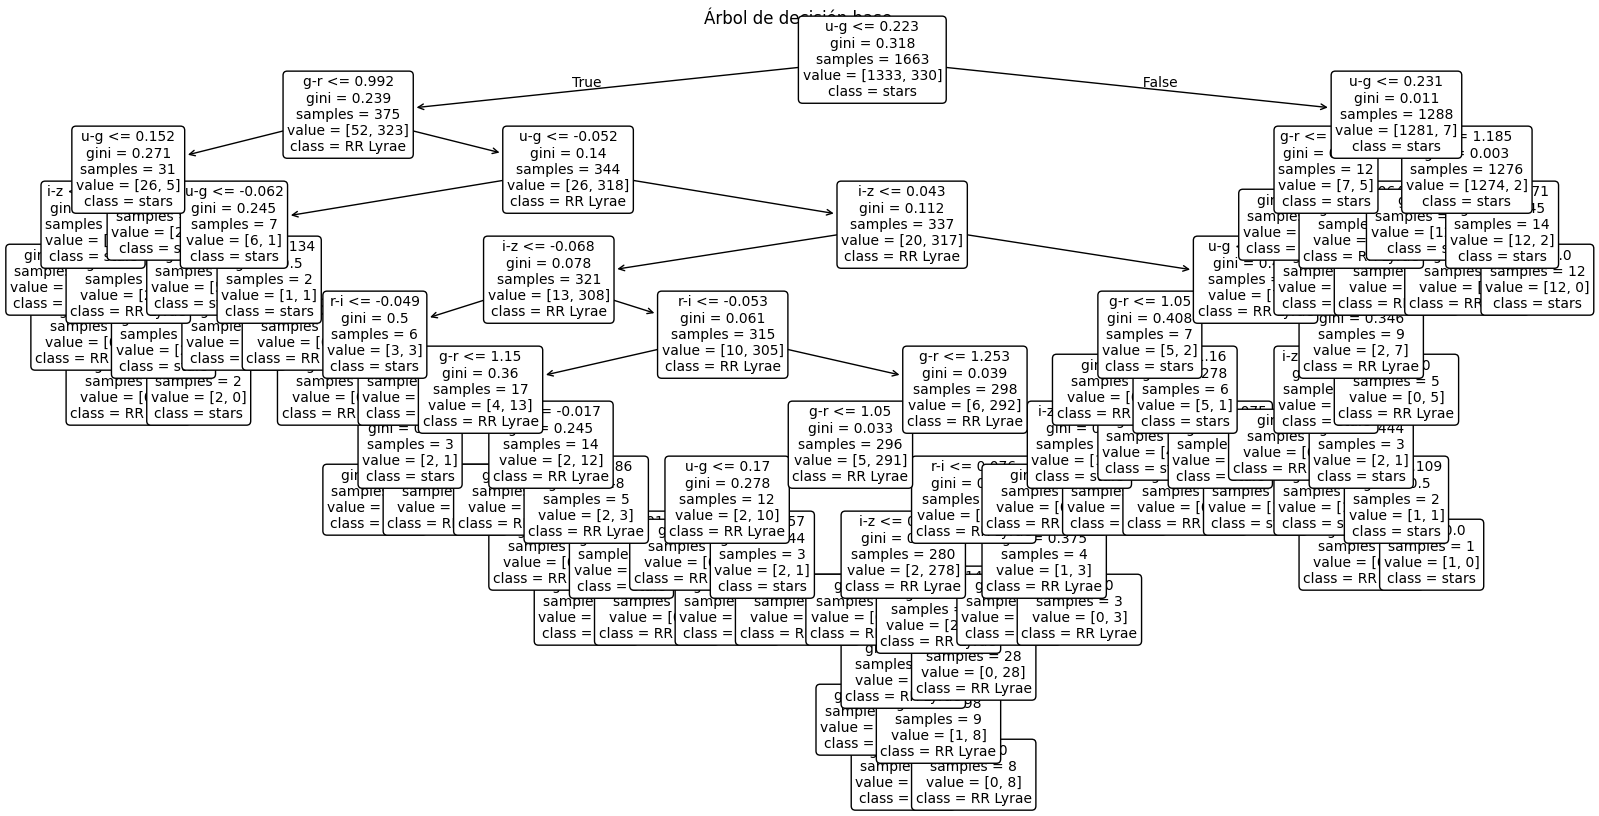

In [11]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

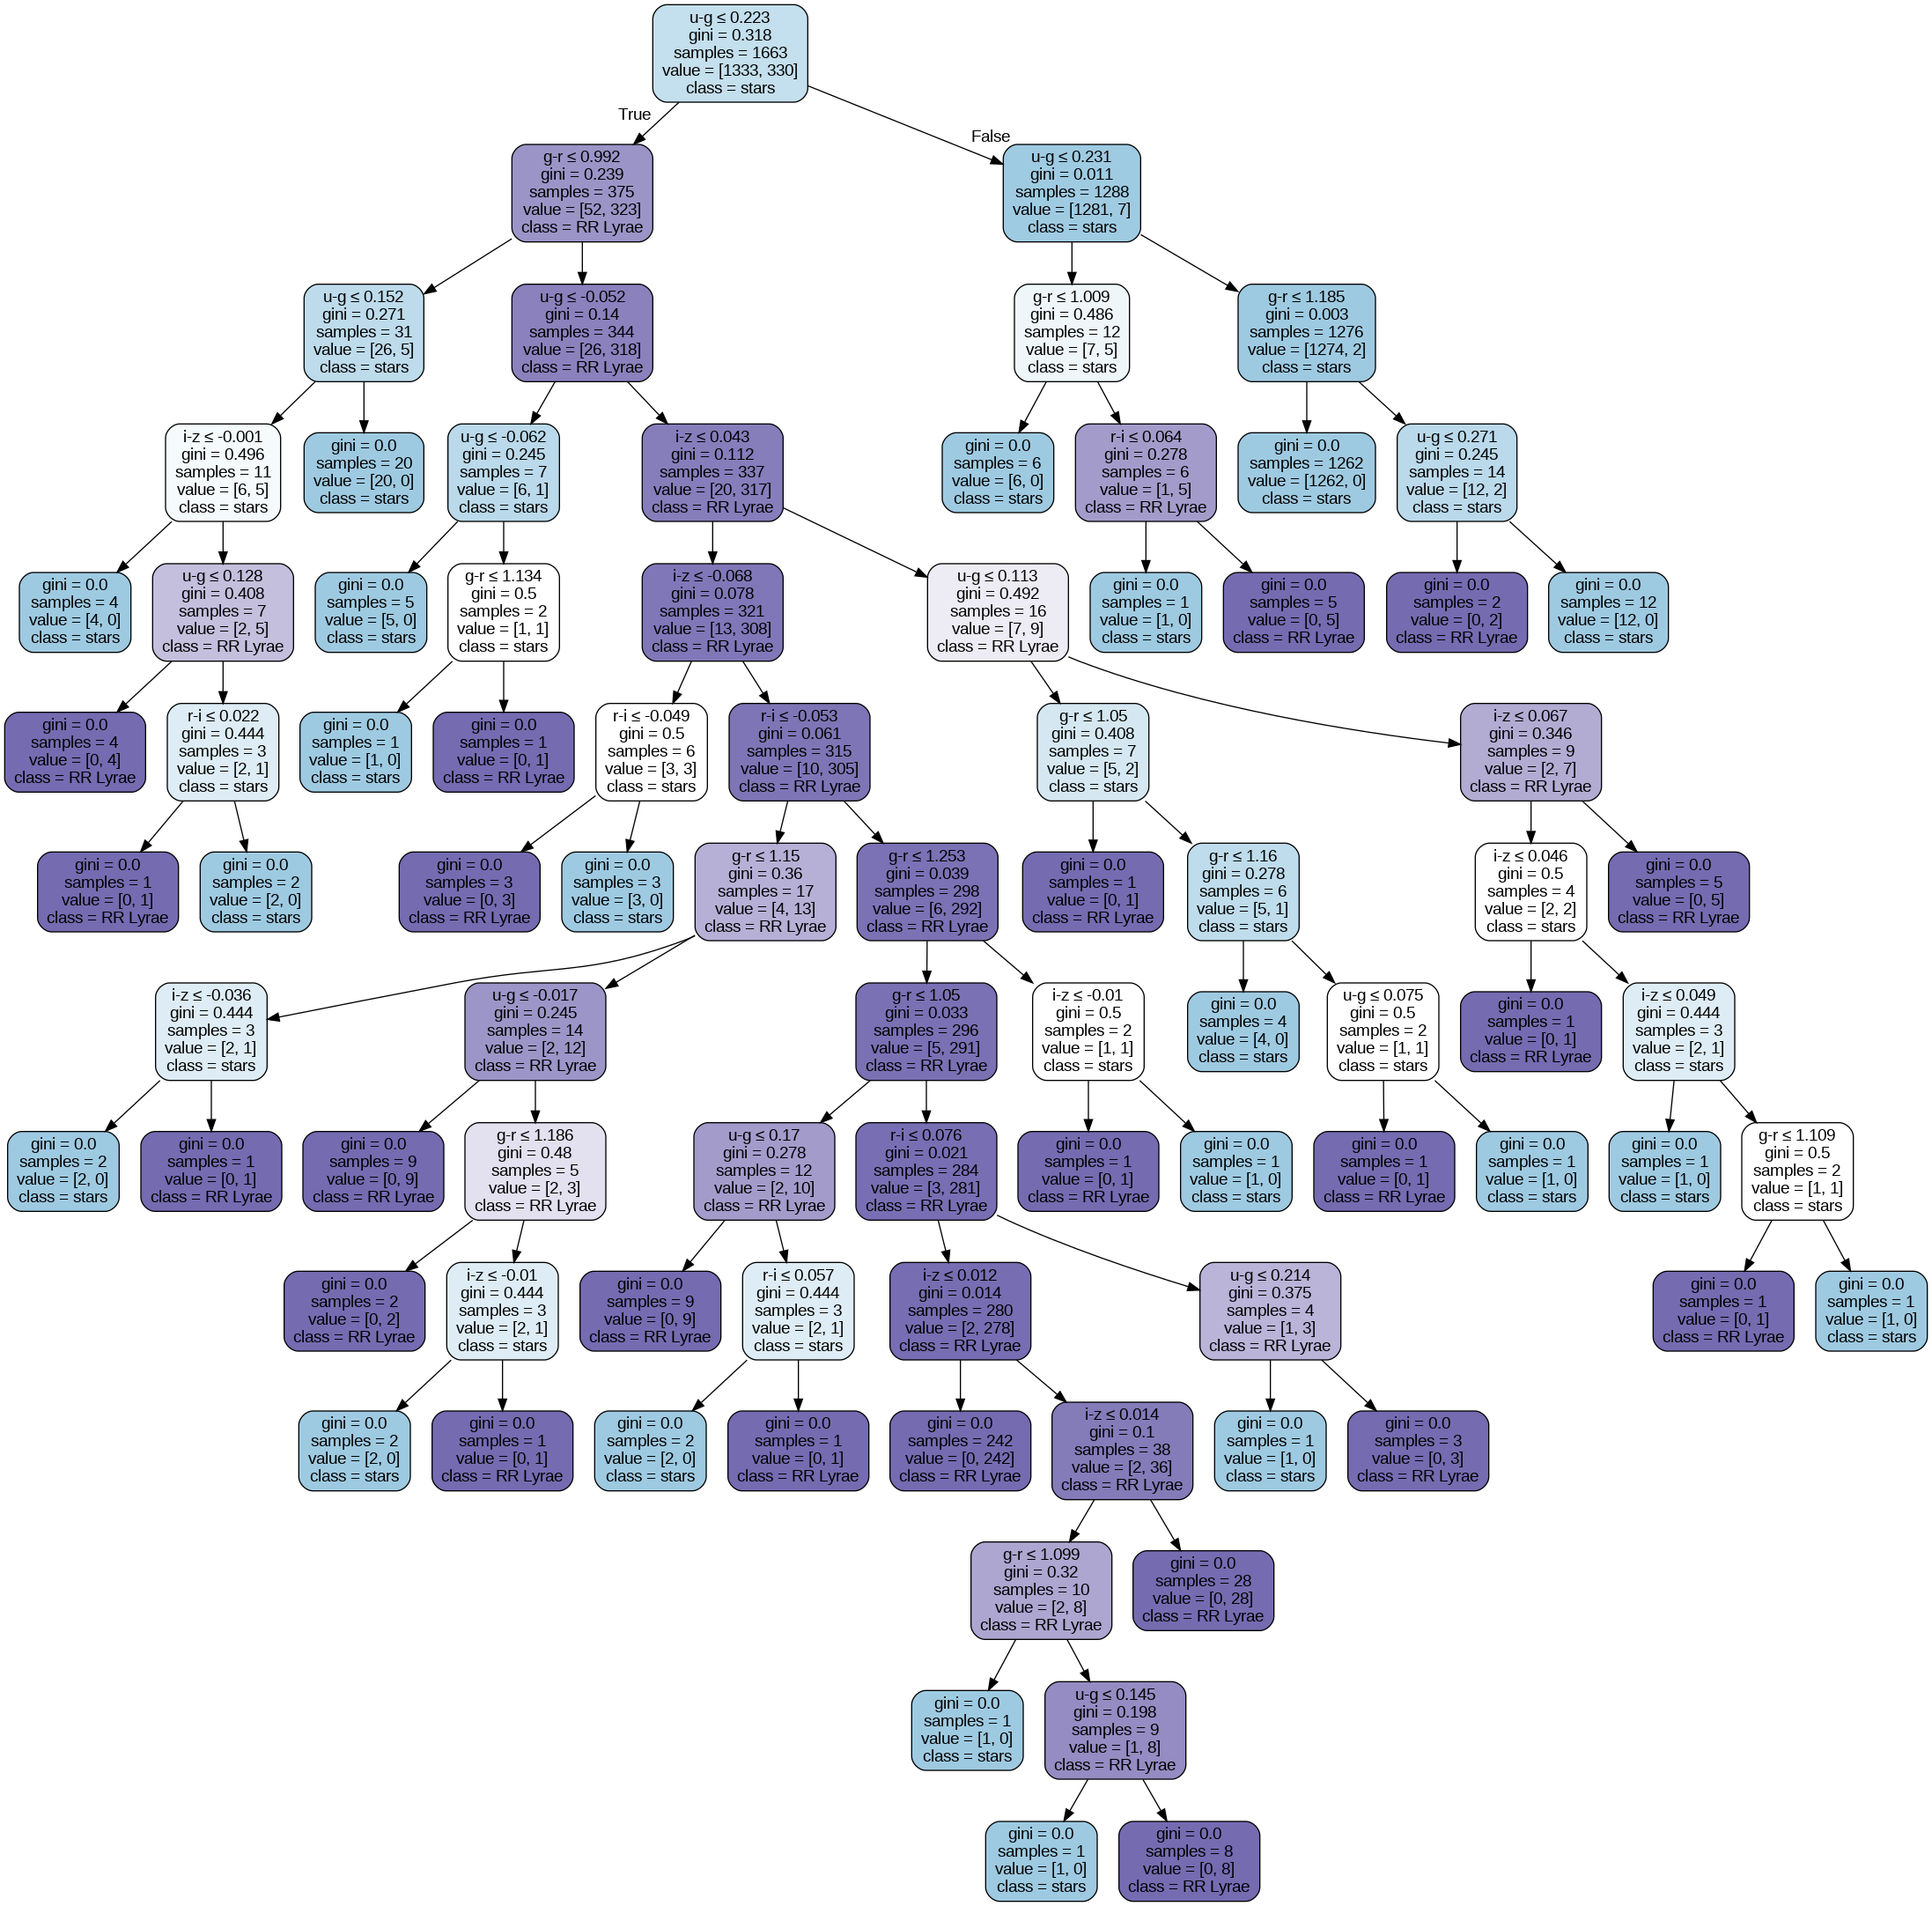

In [12]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

### Preguntas

Observe la estructura del árbol y responda brevemente:

**1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.**

- Muy complejo ya que tiene más de 10 divisiones.

**2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?**

- Es más difícil realizar análisis por la cantidad de "ramas" que posee el árbol.

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [13]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.9670731707317073


#### Otras métricas

In [14]:
y_pred = model_tree.predict(X_test)

In [15]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.9090909090909091
Recall   : 0.9150326797385621
F1-score : 0.9120521172638436


In [16]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[653,  14],
       [ 13, 140]])

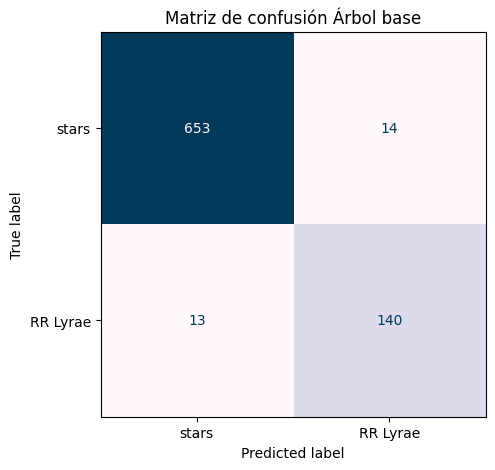

In [17]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP): 140
   - verdaderos negativos (TN): 643
   - falsos positivos (FP): 14
   - falsos negativos (FN): 13
2. Calcule las métricas "a mano"

*Positivo es la clase que nos interesa*

In [18]:
precision_manual = 140 / (140 + 14)
print(precision_manual)

recall_manual = 140 / (140 + 13)
print(recall_manual)

f1_manual = (precision_manual*recall_manual) / (precision_manual + recall_manual)
print(f1_manual)

0.9090909090909091
0.9150326797385621
0.4560260586319218


### Preguntas
**1. Explique con sus palabras qué significa, en este problema:**
   - un falso positivo: que estrellas fueron catalogadas como RR Lyrae.
   - un falso negativo: que RR Lyrae fueron catalogadas como estrellas.

**2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?**

- El falso negativo ya que catalogaste los datos de forma negativa y se catalogaron incorrectamente.

**3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?**

- El falso positivo ya que no queremos que una estrella sea catalogada como RR Lyrae

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [19]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [20]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x79420348b120>

In [21]:
for train, test in cv1.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [22]:
for train, test in cv2.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [23]:
for train, test in cv3.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [24]:
scores1 = cross_validate(model_tree, X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(model_tree, X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(model_tree, X, y, cv = cv3, scoring = 'accuracy')

In [25]:
scores1

{'fit_time': array([0.01645923, 0.01343679, 0.01209927, 0.01046801, 0.00452971]),
 'score_time': array([0.00544286, 0.00309896, 0.00306678, 0.00353098, 0.00297213]),
 'test_score': array([0.98591549, 0.98189135, 0.96981891, 0.96572581, 0.02620968])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [26]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.786 0.380


In [27]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.965 0.012


In [28]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.971 0.004


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [29]:
scores1 = cross_validate(model_tree, X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(model_tree, X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(model_tree, X,y, cv = cv3, scoring = 'recall')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

In [30]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.914 0.033
0.932 0.014


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.

In [31]:
scores1 = cross_validate(model_tree, X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(model_tree, X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(model_tree, X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

In [32]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.914 1.000
0.932 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [33]:
#model1 = DecisionTreeClassifier(random_state = 3)

y_cv3 = cross_val_predict(model_tree, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [34]:
metrics.confusion_matrix(targets,y_cv3)

array([[1961,   39],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [35]:
#model2 = DecisionTreeClassifier(random_state = 3)

y_cv2 = cross_val_predict(model_tree, X,y, cv = cv2)

In [36]:
np.sum(y_cv3-y_cv2)

np.int64(4)

In [37]:
np.sum(y_cv2)

np.int64(485)

In [38]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

np.int64(52)

In [39]:
metrics.confusion_matrix(targets,y_cv2)

array([[1956,   44],
       [  42,  441]])

In [40]:
metrics.confusion_matrix(targets,y_cv3)

array([[1961,   39],
       [  33,  450]])

In [41]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [42]:
#model = DecisionTreeClassifier(random_state = 5)

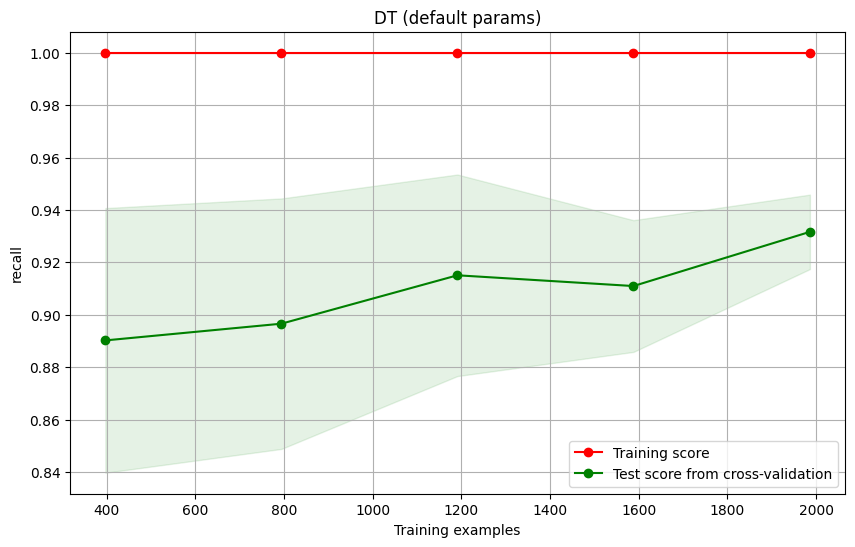

In [43]:
plot_learning_curve(model_tree, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

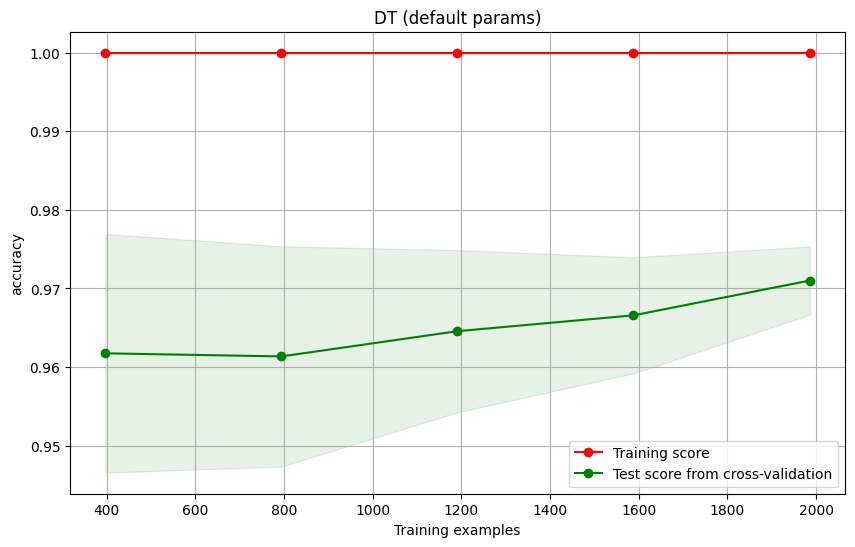

In [44]:
plot_learning_curve(model_tree, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

**1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?**

- Existe una brecha, no tan grande y esto sugiere que el modelo

**2. ¿El rendimiento de validación mejora al agregar más ejemplos?**

**3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.**

- Modelo está sobreajustando, training score es muy perfecto

**4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.**

-

### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



Accuracy entrenamiento: 0.9795550210463019
Accuracy prueba:       0.9719512195121951

Precision: 0.9166666666666666
Recall   : 0.934640522875817
F1-score : 0.9255663430420712
[[654  13]
 [ 10 143]]


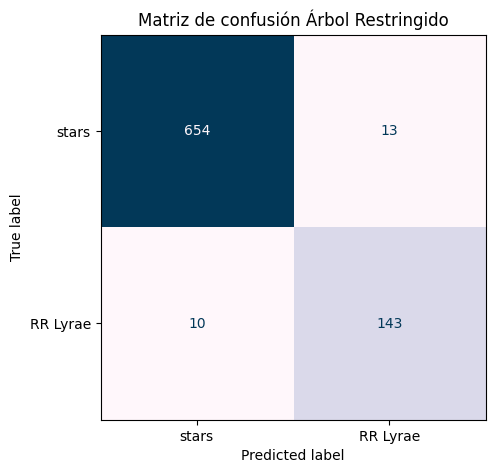

Métrica         Árbol Base      Árbol Restringido
Accuracy        0.9671          0.9720         
Precision       0.9091          0.9167         
Recall          0.9150          0.9346         
F1-score        0.9121          0.9256         


In [47]:
model_tree_restricted = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42)
model_tree_restricted.fit(X_train, y_train)

y_pred_restricted = model_tree_restricted.predict(X_test)

print("Accuracy entrenamiento:", metrics.accuracy_score(y_train, model_tree_restricted.predict(X_train)))
print("Accuracy prueba:      ", metrics.accuracy_score(y_test, y_pred_restricted))
print("\nPrecision:", metrics.precision_score(y_test, y_pred_restricted))
print("Recall   :", metrics.recall_score(y_test, y_pred_restricted))
print("F1-score :", metrics.f1_score(y_test, y_pred_restricted))

cm_restricted = confusion_matrix(y_test, y_pred_restricted)
print(cm_restricted)

fig, ax = plt.subplots(figsize=(5, 5))
disp_restricted = ConfusionMatrixDisplay(confusion_matrix=cm_restricted, display_labels=["stars", "RR Lyrae"])
disp_restricted.plot(cmap="PuBu", ax=ax, colorbar=False)
plt.title("Matriz de confusión Árbol Restringido")
plt.show()

print(f"{'Métrica':<15} {'Árbol Base':<15} {'Árbol Restringido':<15}")
print(f"{'Accuracy':<15} {metrics.accuracy_score(y_test, y_pred):<15.4f} {metrics.accuracy_score(y_test, y_pred_restricted):<15.4f}")
print(f"{'Precision':<15} {metrics.precision_score(y_test, y_pred):<15.4f} {metrics.precision_score(y_test, y_pred_restricted):<15.4f}")
print(f"{'Recall':<15} {metrics.recall_score(y_test, y_pred):<15.4f} {metrics.recall_score(y_test, y_pred_restricted):<15.4f}")
print(f"{'F1-score':<15} {metrics.f1_score(y_test, y_pred):<15.4f} {metrics.f1_score(y_test, y_pred_restricted):<15.4f}")

### Preguntas

A partir de los resultados obtenidos con validación cruzada:

**1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?**

- Al visualizar la matriz de confusión esta se mantuvo casi igual a la anterior, solo que aumentó la clasificación de RR Lyrae.

**2. ¿El árbol más simple empeoró o mejoró la generalización?**

- Mejoró la generalización, se puede evidenciar en la comparación de las métricas.

**3. ¿Qué sugieren estos resultados sobre el árbol base?**

- Que el complejizar el árbol de decisiones no garantiza un mejor modelo de los datos.

**4. En este problema, ¿parece conveniente usar el árbol sin restricciones?**

- En el caso de que necesitaramos una muestra de mayor pureza sería mejor restringirlo ya que minimiza los falsos negativos.

**5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?**

- El Recall ya que si nuestro objetivo es encontrar RR Lyrae, necesitamos minimizar los falsos negativos.

## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.


In [50]:
from sklearn import neighbors
import sklearn

In [70]:
scaler = sklearn.preprocessing.StandardScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_knn = neighbors.KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)

y_pred_knn = model_knn.predict(X_test_scaled)

In [72]:
print(f"{'Métrica':<15} {'Modelo KNN':<15} {'Árbol Restringido':<15}")
print(f"{'Accuracy':<15} {metrics.accuracy_score(y_test, y_pred_knn):<15.4f} {metrics.accuracy_score(y_test, y_pred_restricted):<15.4f}")
print(f"{'Precision':<15} {metrics.precision_score(y_test, y_pred_knn):<15.4f} {metrics.precision_score(y_test, y_pred_restricted):<15.4f}")
print(f"{'Recall':<15} {metrics.recall_score(y_test, y_pred_knn):<15.4f} {metrics.recall_score(y_test, y_pred_restricted):<15.4f}")
print(f"{'F1-score':<15} {metrics.f1_score(y_test, y_pred_knn):<15.4f} {metrics.f1_score(y_test, y_pred_restricted):<15.4f}")

Métrica         Modelo KNN      Árbol Restringido
Accuracy        0.9671          0.9720         
Precision       0.8663          0.9167         
Recall          0.9739          0.9346         
F1-score        0.9169          0.9256         


In [75]:

print(f"{'k':<5} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-score':<12}")

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
for k in k_values:
    model_knn = neighbors.KNeighborsClassifier(n_neighbors=k)
    model_knn.fit(X_train_scaled, y_train)
    y_pred = model_knn.predict(X_test_scaled)

    acc = metrics.accuracy_score(y_test, y_pred)
    prec = metrics.precision_score(y_test, y_pred)
    rec = metrics.recall_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)

    print(f"{k:<5} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

k     Accuracy     Precision    Recall       F1-score    
1     0.9671       0.9038       0.9216       0.9126      
3     0.9646       0.8827       0.9346       0.9079      
5     0.9671       0.8663       0.9739       0.9169      
7     0.9659       0.8655       0.9673       0.9136      
9     0.9671       0.8663       0.9739       0.9169      
11    0.9671       0.8663       0.9739       0.9169      
15    0.9646       0.8605       0.9673       0.9108      
21    0.9659       0.8613       0.9739       0.9141      


### Preguntas

**1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?**

- En ambos modelos el Accuracy son parecidos. Por otro lado mientras precision, recall y f1score se mantienen similares en el modelo del árbol restringido, en el modelo de kNN se observa una mayor diferencia entre precision y recall, siendo este último muy bueno, 97%, y el primero cercano al 86%

**2. ¿Qué ocurre cuando `k` es muy pequeño?**

- Con k=1, la precisión es la más alta de todas (0.9038) pero el recall es el más bajo (0.9216). Esto muestra que el modelo no está recuperando muchos valores de los que deberían ser positivos.


**3. ¿Qué ocurre cuando `k` es muy grande?**

- Con k=21, el recall se mantiene alto (0.9739) pero la precisión cae a 0.8613. Esto indica que el modelo se volvió demasiado permisivo: para no perderse ningún positivo, empieza a clasificar erróneamente negativos como positivos, perdiendo precisión.

**4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?**

- k=5, k=9 y k=11 dan exactamente los mismos resultados: precision 0.8663 y recall 0.9739, con F1 de 0.9169. Cualquiera de estos tres ofrece el mejor equilibrio. k=5 sería la opción más simple.

**5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?**

- Los árboles de decisión generan divisiones en forma de rectángulos, con cortes paralelos a los ejes. En cambio, kNN construye la frontera basándose en la proximidad de los puntos vecinos, lo que le permite adaptarse a separaciones curvas, diagonales o con formas complejas que el árbol no podría capturar por sus limitaciones geométricas.

## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.